In [8]:
!apt-get update
!apt-get install -y libglu1-mesa

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:5 https://cli.github.com/packages stable InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,247 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,602 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,915 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
G

In [9]:
!pip install gmsh meshio scikit-fem pyvista trame

In [10]:
import numpy as np
import gmsh
import meshio
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from scipy.optimize import minimize

from skfem import *
from skfem.models.elasticity import linear_elasticity
from skfem.helpers import sym_grad

In [11]:
# MATERIAL
rho = 7750.0
E = 200e9
nu = 0.27
yield_strength = 700e6

# ROTATION
rpm = 12000
omega = 2 * np.pi * rpm / 60

# GEOMETRY
length = 0.060
width = 0.005
thickness = 0.001

# CUTTING
cutting_force = 30.0  # N per side

In [44]:
def calculate_mixing_efficiency(curvature, taper):
    #simplified heuristic for mixing efficiency: higher curvature and taper are assumed
    #to increase mixing efficiency
    base_efficiency = 20.0
    curvature_contribution = curvature * 10000.0
    taper_contribution = taper * 50.0
    efficiency = base_efficiency + curvature_contribution + taper_contribution
    return max(0.0, min(100.0, efficiency))

def create_blade_mesh(filename,curvature=0.0,taper=0.0,mesh_size=0.001):

    if gmsh.is_initialized():
        gmsh.finalize()
    gmsh.initialize()
    gmsh.model.add("blade")
    L = length / 2
    W = width / 2
    x = np.linspace(-L, L, 80)
    pts_top = []
    pts_bot = []
    for xi in x:
        curve = curvature * np.sin(2*np.pi*xi/length)
        local_half_width = W * (1 - taper * abs(xi)/L)
        local_half_width = max(local_half_width, 0.0005)
        pts_top.append(gmsh.model.geo.addPoint(xi,curve + local_half_width,0,mesh_size))
        pts_bot.append(gmsh.model.geo.addPoint(xi,curve - local_half_width,0,mesh_size))

    top = gmsh.model.geo.addSpline(pts_top)
    right = gmsh.model.geo.addLine(pts_top[-1],pts_bot[-1])
    bottom = gmsh.model.geo.addSpline(pts_bot[::-1])
    left = gmsh.model.geo.addLine(pts_bot[0],pts_top[0])
    loop = gmsh.model.geo.addCurveLoop([top, right, bottom, left])

    surf = gmsh.model.geo.addPlaneSurface([loop])
    gmsh.model.geo.synchronize()
    gmsh.model.addPhysicalGroup(1, [right], name="right_edge")
    gmsh.model.addPhysicalGroup(1, [left], name="left_edge")
    gmsh.model.addPhysicalGroup(2, [surf], name="blade")
    gmsh.model.mesh.generate(2)
    gmsh.write(filename)
    gmsh.finalize()

def solve_blade(meshfile,cutting_force=30.0):
    mesh = MeshTri.load(meshfile)
    basis = Basis(mesh,ElementVector(ElementTriP2()))
    lame_mu = E / (2 * (1 + nu))
    lame_lambda = E * nu / ((1 + nu) * (1 - nu))
    K = asm(linear_elasticity(lame_lambda,lame_mu),basis)

    # CENTRIFUGAL BODY FORCE
    @LinearForm
    def body_force(v, w):
        x = w.x[0]
        y = w.x[1]
        return ( rho*thickness*omega**2*x*v[0] + rho*thickness*omega**2*y*v[1])
    f = asm(body_force, basis)

    right_edge_facets = mesh.boundaries['right_edge']
    left_edge_facets = mesh.boundaries['left_edge']
    right_edge_nodes_indices = np.unique(mesh.facets[:, right_edge_facets])
    left_edge_nodes_indices = np.unique(mesh.facets[:, left_edge_facets])
    fr = (cutting_force / thickness) / len(right_edge_nodes_indices)
    fl = (cutting_force / thickness) / len(left_edge_nodes_indices)

    for n_idx in right_edge_nodes_indices:
        f[basis.nodal_dofs[1, n_idx]] -= fr
    for n_idx in left_edge_nodes_indices:
        f[basis.nodal_dofs[1, n_idx]] += fl

    D = basis.get_dofs(
        lambda x:
        np.sqrt(x[0]**2 + x[1]**2)
        < 0.003
    ).all()

    x_sol = solve(*condense(K, f, D=D))

    # VON MISES STRESS
    def von_mises(w):
        eps = sym_grad(w)
        tr = eps[0,0] + eps[1,1]
        s00 = lame_lambda*tr + 2*lame_mu*eps[0,0]
        s11 = lame_lambda*tr + 2*lame_mu*eps[1,1]
        s01 = 2*lame_mu*eps[0,1]
        return np.sqrt(s00**2+s11**2-s00*s11+3*s01**2)

    s_basis = basis.with_element(ElementTriP1())
    stress = s_basis.project(von_mises(basis.interpolate(x_sol)))
    ux = x_sol[basis.nodal_dofs[0]]
    uy = x_sol[basis.nodal_dofs[1]]
    disp = np.sqrt(ux**2 + uy**2)

    return {
        "mesh": mesh,
        "stress": stress,
        "max_stress": np.max(stress),
        "displacement": disp,
        "max_displacement": np.max(disp)
    }

def solve_blade_plane_strain(meshfile,cutting_force=30.0):
    mesh = MeshTri.load(meshfile)
    basis = Basis(mesh,ElementVector(ElementTriP2()))

    lame_mu = E / (2 * (1 + nu))
    lame_lambda = E * nu / ((1 + nu) * (1 - 2 * nu))
    K = asm(linear_elasticity(lame_lambda,lame_mu),basis)

    # CENTRIFUGAL BODY FORCE
    @LinearForm
    def body_force(v, w):
        x = w.x[0]
        y = w.x[1]
        return (rho*thickness*omega**2*x*v[0] + rho*thickness*omega**2*y*v[1])
    f = asm(body_force, basis)

    right_edge_facets = mesh.boundaries['right_edge']
    left_edge_facets = mesh.boundaries['left_edge']
    right_edge_nodes_indices = np.unique(mesh.facets[:, right_edge_facets])
    left_edge_nodes_indices = np.unique(mesh.facets[:, left_edge_facets])
    fr = (cutting_force / thickness) / len(right_edge_nodes_indices)
    fl = (cutting_force / thickness) / len(left_edge_nodes_indices)

    for n_idx in right_edge_nodes_indices:
        f[basis.nodal_dofs[1, n_idx]] -= fr

    for n_idx in left_edge_nodes_indices:
        f[basis.nodal_dofs[1, n_idx]] += fl

    D = basis.get_dofs(
        lambda x:
        np.sqrt(x[0]**2 + x[1]**2)
        < 0.003
    ).all()

    x_sol = solve(*condense(K, f, D=D))

    # VON MISES STRESS
    def von_mises(w):
      eps = sym_grad(w)
      tr = eps[0,0] + eps[1,1]
      s00 = lame_lambda*tr + 2*lame_mu*eps[0,0]
      s11 = lame_lambda*tr + 2*lame_mu*eps[1,1]
      s01 = 2*lame_mu*eps[0,1]

      # plane strain
      s22 = lame_lambda * tr

      # Von Mises stress
      return np.sqrt(s00**2+ s11**2+ s22**2- s00*s11- s11*s22- s22*s00+ 3*s01**2)

    s_basis = basis.with_element(ElementTriP1())
    stress = s_basis.project(von_mises(basis.interpolate(x_sol)))
    ux = x_sol[basis.nodal_dofs[0]]
    uy = x_sol[basis.nodal_dofs[1]]
    disp = np.sqrt(ux**2 + uy**2)
    return {
        "mesh": mesh,
        "stress": stress,
        "max_stress": np.max(stress),
        "displacement": disp,
        "max_displacement": np.max(disp)
    }

def plot_result(result, title):

    mesh = result["mesh"]
    tri = mtri.Triangulation(mesh.p[0],mesh.p[1],mesh.t.T)
    fig, ax = plt.subplots(1,2,figsize=(14,5))

    # Displacement
    t1 = ax[0].tripcolor(tri,result["displacement"],shading='gouraud')

    cbar1 = fig.colorbar(t1, ax=ax[0])
    cbar1.ax.tick_params(labelsize=12)
    max_disp_mm = np.max(result["displacement"]) * 1000
    model_suffix = ""
    if "(" in title:
        model_suffix = " " + title[title.find("("):]
    ax[0].set_title(f"Displacement{model_suffix}\nMax = {max_disp_mm:.4f} mm", fontsize=14)
    ax[0].axis('equal')

    # Stress
    t2 = ax[1].tripcolor(tri,result["stress"],shading='gouraud',cmap='jet')

    cbar2 = fig.colorbar(t2, ax=ax[1])
    cbar2.ax.tick_params(labelsize=12)
    efficiency_str = ""
    if 'mixing_efficiency' in result:
        efficiency_str = f"\nEfficiency = {result['mixing_efficiency']:.1f}%"
    ax[1].set_title(
        f"{title}\n"
        f"Max Stress = "
        f"{result['max_stress']/1e6:.1f} MPa"
        f"{efficiency_str}",
        fontsize=14
    )
    ax[1].axis('equal')
    plt.tight_layout()
    plt.show()

def solve_blade_plane_strain_corrected(meshfile, cutting_force=30.0):
    mesh = MeshTri.load(meshfile)
    basis = Basis(mesh, ElementVector(ElementTriP2()))
    lame_mu = E / (2 * (1 + nu))
    lame_lambda = E * nu / ((1 + nu) * (1 - 2 * nu))
    K = asm(linear_elasticity(lame_lambda, lame_mu), basis)

    # Centrifugal force
    @LinearForm
    def body_force(v, w):
        return rho * thickness * omega**2 * (w.x[0] * v[0] + w.x[1] * v[1])
    f = asm(body_force, basis)

    # Cutting force
    for side, sign in [('right_edge', -1), ('left_edge', 1)]:
        nodes = np.unique(mesh.facets[:, mesh.boundaries[side]])
        f_node = (cutting_force / thickness) / len(nodes)
        for n_idx in nodes:
            f[basis.nodal_dofs[1, n_idx]] += sign * f_node

    # Hub Constraint (for FEM nodes simulation)
    D = basis.get_dofs(lambda x: np.sqrt(x[0]**2 + x[1]**2) < 0.003).all()
    x_sol = solve(*condense(K, f, D=D))

    def von_mises_3d(w):
        eps = sym_grad(w)
        tr = eps[0,0] + eps[1,1]
        s00 = lame_lambda*tr + 2*lame_mu*eps[0,0]
        s11 = lame_lambda*tr + 2*lame_mu*eps[1,1]
        s01 = 2*lame_mu*eps[0,1]
        s22 = lame_lambda * tr # The out-of-plane stress
        return np.sqrt(s00**2 + s11**2 + s22**2 - s00*s11 - s11*s22 - s22*s00 + 3*s01**2)

    s_basis = basis.with_element(ElementTriP1())
    stress = s_basis.project(von_mises_3d(basis.interpolate(x_sol)))
    disp = np.sqrt(x_sol[basis.nodal_dofs[0]]**2 + x_sol[basis.nodal_dofs[1]]**2)
    return {"mesh": mesh, "stress": stress, "max_stress": np.max(stress), "displacement": disp}

## Part 1: Baseline Comparison (Plane Stress vs. Plane Strain)
We start by comparing the two constitutive models on a standard rectangular blade to see how the assumptions affect the results.



Rectangular blade max stress (plane stress): 178.77 MPa
Rectangular blade max stress (plane strain): 159.82 MPa


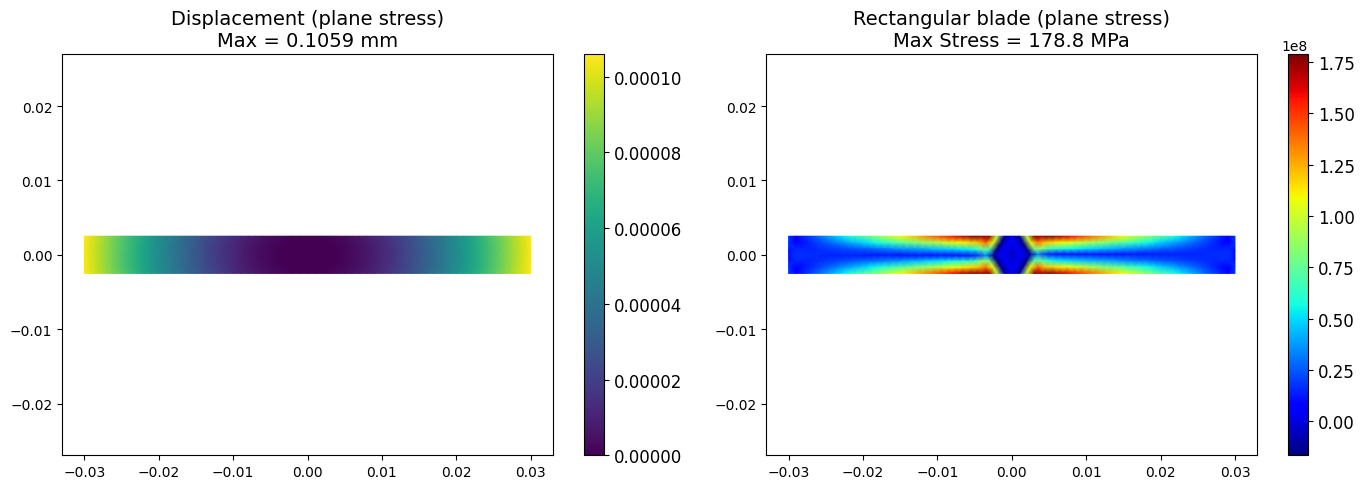

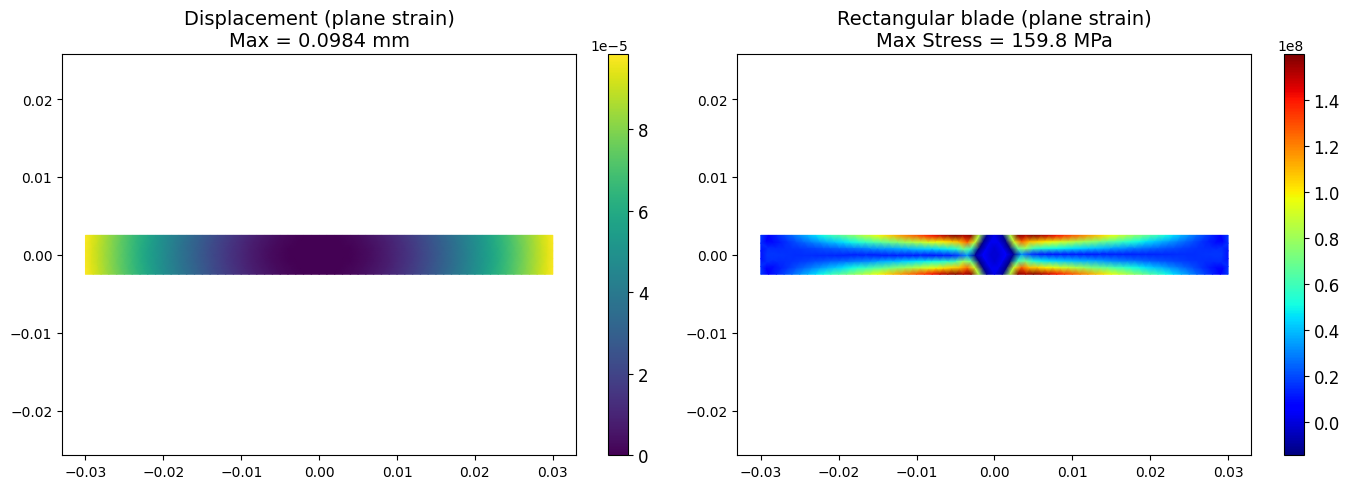

In [53]:
create_blade_mesh('rect.msh', curvature=0.0, taper=0.0)
res_stress = solve_blade('rect.msh')
res_strain = solve_blade_plane_strain_corrected('rect.msh')

print(f"Rectangular blade max stress (plane stress): {res_stress['max_stress']/1e6:.2f} MPa")
print(f"Rectangular blade max stress (plane strain): {res_strain['max_stress']/1e6:.2f} MPa")

plot_result(res_stress, "Rectangular blade (plane stress)")
plot_result(res_strain, "Rectangular blade (plane strain)")

## Part 2: Parameter Optimization
We now optimize the blade parameters sequentially using the plane stress model:
1. **Curvature Optimization**: Maximize mixing efficiency under the safety constraint.
2. **Wedge Angle (Taper) Optimization**: Improving flow and reducing mass.

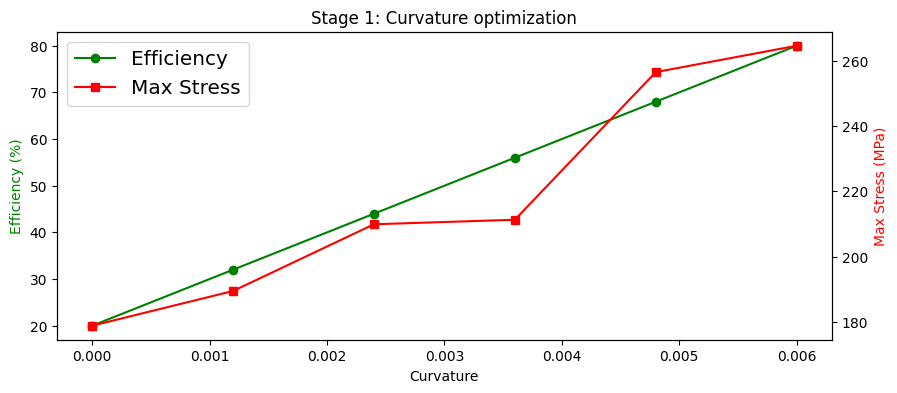

In [46]:
import pandas as pd

curv_range = np.linspace(0.0, 0.006, 6)
curv_results = []

for c in curv_range:
    create_blade_mesh('temp.msh', curvature=c, taper=0.0)
    sol = solve_blade('temp.msh')
    curv_results.append({'curvature': c, 'stress': sol['max_stress']/1e6, 'eff': calculate_mixing_efficiency(c, 0.0)})

df_curv = pd.DataFrame(curv_results)
fig, ax1 = plt.subplots(figsize=(10, 4))

lns1 = ax1.plot(df_curv['curvature'], df_curv['eff'], 'g-o', label='Efficiency')
ax1.set_ylabel('Efficiency (%)', color='g')
ax1.set_xlabel('Curvature')

ax2 = ax1.twinx()
lns2 = ax2.plot(df_curv['curvature'], df_curv['stress'], 'r-s', label='Max Stress')
ax2.set_ylabel('Max Stress (MPa)', color='r')

# Combine legends and make them larger
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize='x-large')

plt.title("Stage 1: Curvature optimization")
plt.show()

best_c = df_curv.loc[df_curv['stress'] < 600, 'curvature'].iloc[-1]

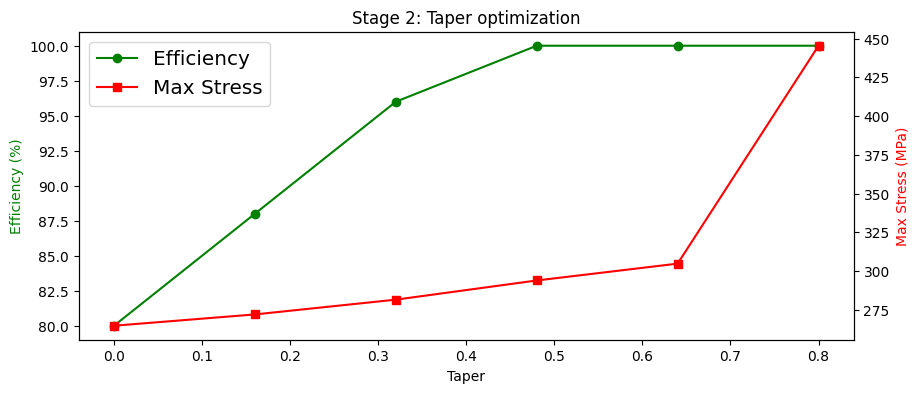

In [47]:
taper_range = np.linspace(0.0, 0.8, 6)
taper_results = []

for t in taper_range:
    create_blade_mesh('temp.msh', curvature=best_c, taper=t)
    sol = solve_blade('temp.msh')
    taper_results.append({'taper': t, 'stress': sol['max_stress']/1e6, 'eff': calculate_mixing_efficiency(best_c, t)})

df_taper = pd.DataFrame(taper_results)
fig, ax1 = plt.subplots(figsize=(10, 4))

lns1 = ax1.plot(df_taper['taper'], df_taper['eff'], 'g-o', label='Efficiency')
ax1.set_ylabel('Efficiency (%)', color='g')
ax1.set_xlabel('Taper')

ax2 = ax1.twinx()
lns2 = ax2.plot(df_taper['taper'], df_taper['stress'], 'r-s', label='Max Stress')
ax2.set_ylabel('Max Stress (MPa)', color='r')

# Combine legends and make them larger
lns = lns1 + lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize='x-large')

plt.title("Stage 2: Taper optimization")
plt.show()

best_t = df_taper.loc[df_taper['stress'] < 650, 'taper'].iloc[-1]

## Mixing efficiency optimized Blade
Below is the result for the best fit blade found during the mixing optimization process.

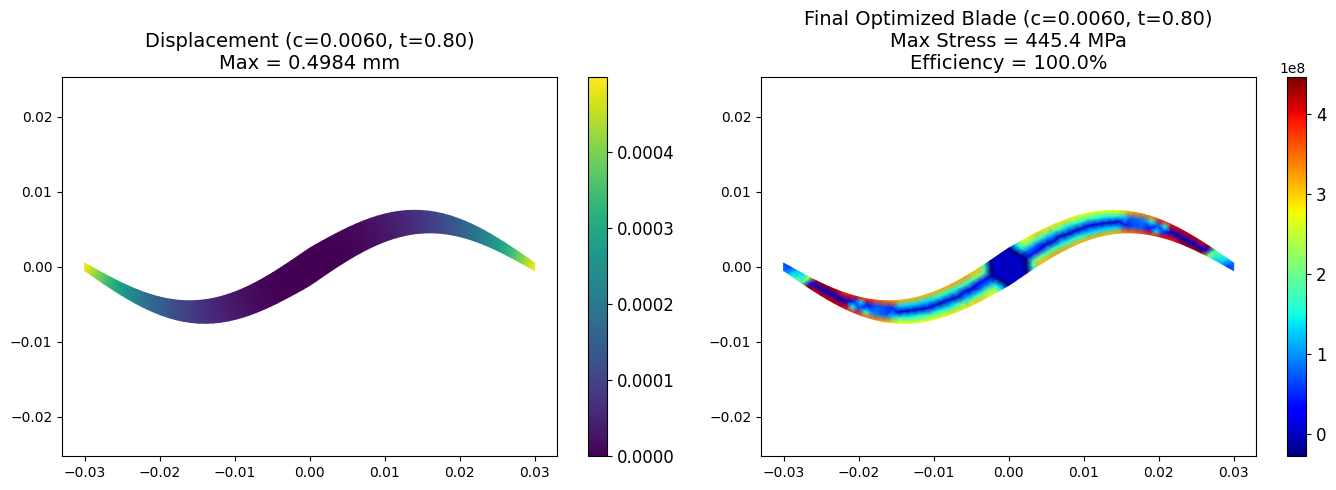

In [48]:
create_blade_mesh('final.msh', curvature=best_c, taper=best_t)
final_res = solve_blade('final.msh')
final_res['mixing_efficiency'] = calculate_mixing_efficiency(best_c, best_t)
plot_result(final_res, f"Final Optimized Blade (c={best_c:.4f}, t={best_t:.2f})")

### Efficiency boost: curvature and tapered width
In this section, we compare two designs to see how the tapered width parameter boosts the performance of the blade.

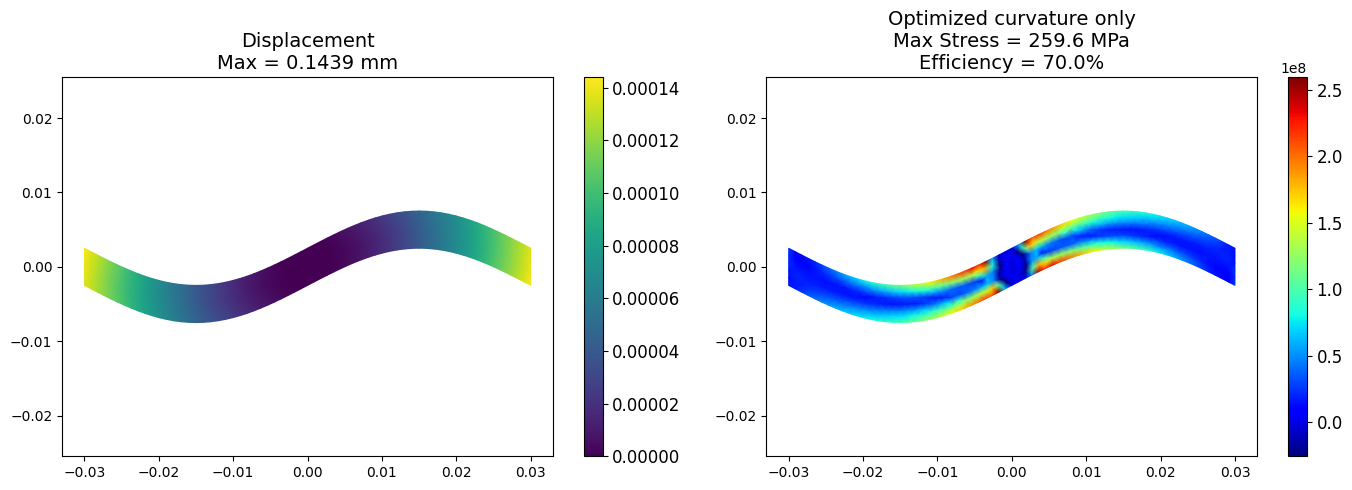

In [49]:
# Case 1: Curvature only (No Taper)
c_demo = 0.005
t_none = 0.0

create_blade_mesh('demo_curv_only.msh', curvature=c_demo, taper=t_none)
res_curv_only = solve_blade('demo_curv_only.msh')
res_curv_only['mixing_efficiency'] = calculate_mixing_efficiency(c_demo, t_none)

plot_result(res_curv_only, "Optimized curvature only")

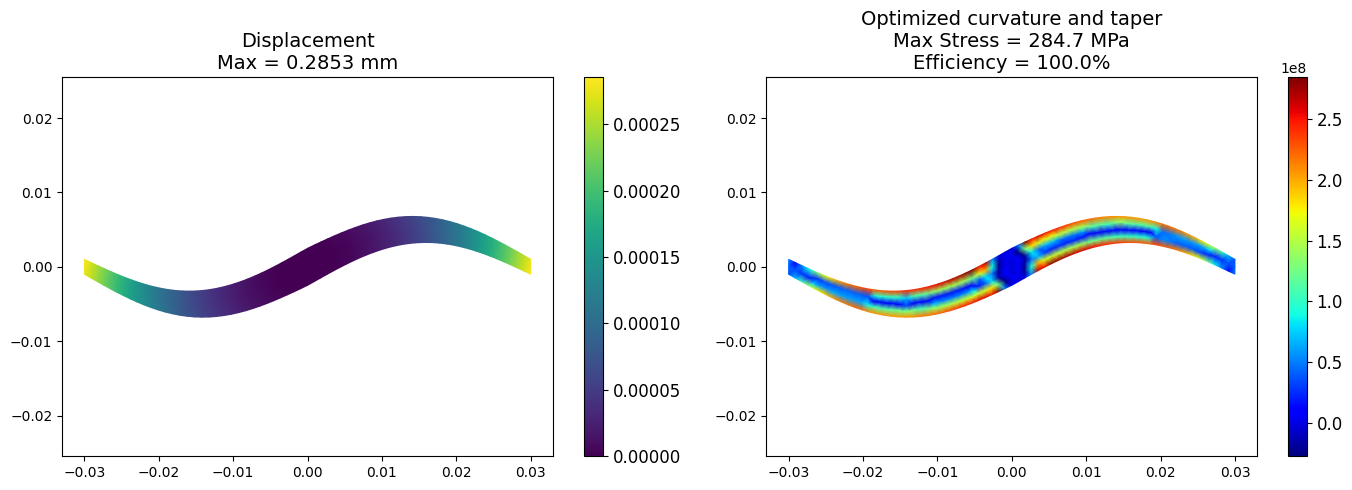

In [50]:
# Case 2: Curvature + Taper
t_demo = 0.6

create_blade_mesh('demo_combined.msh', curvature=c_demo, taper=t_demo)
res_combined = solve_blade('demo_combined.msh')
res_combined['mixing_efficiency'] = calculate_mixing_efficiency(c_demo, t_demo)

plot_result(res_combined, "Optimized curvature and taper")

### Conclusion
As the different plots and graphs show us:
- **Step A** gives the distribution for a blade that is structurally safe but functionally incomplete (70% efficiency).
- **Step B** shows that adding the taper provides the efficiency boost required to reach 100%. While the stress increases due to the thinner edges, the design remains well below the yield limit, confirming that combining both parameters is the most efficient way to reach the design goals.

### Final optimized design parameters
Here are the parameters of the efficiency and taper optimized blade, designed with respect to the safety factor of 2.

In [51]:

final_c = 0.005
final_t = 0.6

create_blade_mesh('consistency_check.msh', curvature=final_c, taper=final_t, mesh_size=0.001)
final_check_res = solve_blade('consistency_check.msh')
final_check_res['mixing_efficiency'] = calculate_mixing_efficiency(final_c, final_t)

print(f"Curvature: {final_c}")
print(f"Taper: {final_t}")
print(f"Estimated mixing efficiency: {final_check_res['mixing_efficiency']:.1f}%")
print(f"Max stress: {final_check_res['max_stress']/1e6:.2f} MPa")
print(f"Safety factor: {yield_strength / final_check_res['max_stress']:.2f}")



Curvature: 0.005
Taper: 0.6
Estimated mixing efficiency: 100.0%
Max stress: 284.69 MPa
Safety factor: 2.46


### Ultimate strength and fatigue
We finally evaluate the limits of our design for ultimate strength failure, motor stalling and fatigue failure.

In [52]:
import numpy as np

current_force = 30.0
current_max_stress = 284.69e6 # From previous run
yield_limit = 700e6

max_allowable_force = (yield_limit / current_max_stress) * current_force

print(f"Max Allowable Cutting Force: {max_allowable_force:.1f} N")

# FATIGUE LIMIT
Se = 0.45 * yield_limit
print(f"Fatigue Limit: {Se / 1e7:.1f} x 10^7 cycles")

# STALLED MOTOR SCENARIO
stall_torque = 2.0
hub_radius = 0.003
root_width = width
# Stress approx = My/I for a beam
section_modulus = (thickness * root_width**2) / 6
stall_stress = (stall_torque) / section_modulus

print(f"Stress during stall: {stall_stress/1e6:.1f} MPa")

if stall_stress > yield_limit:
    print("Result: The blade will yield immediately (under 1 second) when the motor is stalled.")
else:
    print(f"Result: The blade will not yield, but it is under {stall_stress/yield_limit*100:.1f}% of its yield capacity.")

Max Allowable Cutting Force: 73.8 N
Fatigue Limit: 31.5 x 10^7 cycles
Stress during stall: 480.0 MPa
Result: The blade will not yield, but it is under 68.6% of its yield capacity.
